# Enhanced β-VAE 통합 임베딩 시스템

이 노트북은 기존 `unified_beta_vae.ipynb`의 아이디어를 기반으로 다음과 같은 **7가지 핵심 개선사항**을 통합하여 완전한 임베딩 시스템으로 발전시킨 버전입니다.

### 🔥 7가지 핵심 개선사항

1.  **Enhanced Loss Function (개선된 손실 함수)**
    - **MSE → Huber Loss**: 이상치(outlier)에 덜 민감하여 훈련 안정성 향상
    - **ArcFace Teacher Loss**: VAE의 잠재 벡터(z)가 ArcFace의 원본 벡터(origin)와 코사인 유사도가 높아지도록 유도하여, 재구성 품질과 의미론적 일관성을 모두 확보합니다.
    - **Margin 기반 Cosine Loss**: `relu(margin - cosine_sim)` 형태를 사용하여, 유사도가 특정 임계값(e.g., 0.95) 이상으로 충분히 가까워지면 손실을 0으로 만들어, 불필요한 그래디언트 업데이트를 방지하고 모델이 더 중요한 다른 학습에 집중하도록 합니다.

2.  **KL Annealing (KL 어닐링)**
    - **KL항 동적 조절**: 훈련 초기에 KL Divergence 항의 가중치를 낮게 시작하여 모델이 재구성에 집중하게 하고, 점진적으로 가중치를 높여 잠재 공간이 정규분포를 따르도록 유도합니다. (Posterior Collapse 방지)
    - **Freeze Epochs**: 훈련 시작 후 몇 에포크 동안 KL 항의 가중치를 0으로 고정하여, 모델이 데이터의 기본적인 특징을 먼저 학습하도록 안정화 기간을 부여합니다.

3.  **Latent Space Visualization (잠재 공간 시각화)**
    - **다차원 분석**: PCA, 클러스터링(K-Means) 등 다양한 기법으로 학습된 잠재 공간의 품질을 심층적으로 분석하고 시각화합니다. (활성 차원, 분산 설명력, 클러스터 품질 등)

4.  **Cosine Similarity Monitoring (코사인 유사도 모니터링)**
    - **실시간 추적**: `latent vector(z)`와 `origin vector` 간의 코사인 유사도를 에포크마다 추적하고, 그 추이와 분포를 시각화하여 ArcFace Teacher 학습이 잘 진행되고 있는지 직관적으로 파악합니다.

5.  **Advanced Training Management (고급 훈련 관리)**
    - **Enhanced Early Stopping**: 검증 손실뿐만 아니라, 코사인 유사도가 특정 임계값 이하로 떨어지는 경우에도 조기 종료를 발동시켜, 품질이 낮은 모델이 생성되는 것을 방지합니다.
    - **엄격한 모델 저장**: 단순히 검증 손실이 개선될 때만이 아니라, **검증 손실 개선과 코사인 유사도 임계값 충족**이라는 두 가지 조건을 모두 만족할 때만 최적 모델을 저장하여, 고품질의 임베딩 모델만 선별합니다.

6.  **Band-Specific Models (주파수 대역별 특화)**
    - 이 노트북에서는 Wavelet과 DCT 데이터를 통합하여 처리하지만, 향후 각 데이터의 특성에 맞는 별도 모델을 훈련할 수 있는 구조적 기반을 제공합니다.

7.  **Comprehensive Evaluation (종합 평가 및 자동화)**
    - **재현성 확보**: 전역 시드 고정, DB 쿼리 정렬, 결정적 데이터 매핑 등 3가지 핵심 요소를 통해 동일한 파라미터로 실행 시 항상 동일한 결과를 보장합니다.
    - **DB 완전 자동화**: 데이터 로딩부터 전처리, 훈련, 평가, 그리고 최종 임베딩 저장까지 모든 과정이 실제 PostgreSQL DB와 연동되어 파이프라인으로 자동화됩니다.
    - **상세 메타데이터 저장**: 최종 임베딩과 함께 사용된 모든 하이퍼파라미터, 훈련 성능 지표, 잠재 공간 분석 결과 등 상세한 메타데이터를 JSON 형태로 함께 저장하여, 실험 결과를 완벽하게 추적하고 재현할 수 있도록 합니다.

In [1]:
# 🔧 재현성 보장: 전역 시드 고정 (1/3)
print("🎯 재현성 확보를 위한 전역 시드 고정 중...")

import random
import numpy as np
import torch

# 시드 고정
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # GPU 사용 시
torch.backends.cudnn.deterministic = True  # ⚠️ 주의: 속도 감소 가능
torch.backends.cudnn.benchmark = False  # 성능 최적화 비활성화 (재현성 우선)

print(f"✅ 전역 시드 {seed}로 고정 완료 (CPU/GPU 모두 포함)")
print("   🎯 random, numpy, torch, cuda 모든 난수 생성기 동기화")
print("   ⚠️  속도 감소 가능하지만 완전한 재현성 보장")

🎯 재현성 확보를 위한 전역 시드 고정 중...
✅ 전역 시드 42로 고정 완료 (CPU/GPU 모두 포함)
   🎯 random, numpy, torch, cuda 모든 난수 생성기 동기화
   ⚠️  속도 감소 가능하지만 완전한 재현성 보장


In [2]:
# JSON 안전 변환 함수 추가 (타입 변환 문제 해결)
def safe_json_convert(obj):
    """JSON 직렬화를 위한 안전한 타입 변환
    
    문제 해결:
    - NumPy 타입 (np.float32, np.int64 등) → Python 기본 타입
    - NaN, Infinity 값 → 안전한 값/문자열
    - Tensor 객체 → NumPy 배열 → 리스트
    """
    import numpy as np
    import torch
    
    if obj is None:
        return None
    elif isinstance(obj, (np.integer, np.int8, np.int16, np.int32, np.int64)):
        return int(obj)  # NumPy 정수 → Python int
    elif isinstance(obj, (np.floating, np.float16, np.float32, np.float64)):
        # NaN, Inf 처리
        if np.isnan(obj):
            return None  # 또는 "NaN"
        elif np.isinf(obj):
            return "Infinity" if obj > 0 else "-Infinity"
        else:
            return float(obj)  # NumPy float → Python float
    elif isinstance(obj, np.ndarray):
        return [safe_json_convert(item) for item in obj.tolist()]
    elif isinstance(obj, torch.Tensor):
        return safe_json_convert(obj.detach().cpu().numpy())
    elif isinstance(obj, (list, tuple)):
        return [safe_json_convert(item) for item in obj]
    elif isinstance(obj, dict):
        return {key: safe_json_convert(value) for key, value in obj.items()}
    elif isinstance(obj, str):
        return obj
    elif isinstance(obj, (int, float, bool)):
        # 기본 Python 타입 확인
        if isinstance(obj, float):
            if np.isnan(obj):
                return None
            elif np.isinf(obj):
                return "Infinity" if obj > 0 else "-Infinity"
        return obj
    else:
        # 직렬화할 수 없는 객체는 문자열로 변환
        try:
            return str(obj)
        except:
            return f"<{type(obj).__name__}>"

print("✅ JSON 안전 변환 함수 정의 완료")
print("   🔧 NumPy 타입 → Python 기본 타입 변환")
print("   🔧 NaN/Infinity 값 안전 처리")
print("   🔧 Tensor 객체 자동 변환")

✅ JSON 안전 변환 함수 정의 완료
   🔧 NumPy 타입 → Python 기본 타입 변환
   🔧 NaN/Infinity 값 안전 처리
   🔧 Tensor 객체 자동 변환


In [3]:
# 🚀 Enhanced β-VAE 통합 임베딩 시스템
# 기존 unified_beta_vae.ipynb + 7가지 핵심 개선사항 통합
# 1. Enhanced Loss Function 2. KL Annealing 3. Latent Visualization 
# 4. Cosine Monitoring 5. Recall@K 6. Band-Specific Models 7. Comprehensive Evaluation

# OpenMP 충돌 문제 해결 (Intel OpenMP와 LLVM OpenMP 충돌 방지)
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'  # Intel OpenMP 중복 로딩 허용

# threadpoolctl 경고 무시 (OpenMP 충돌 관련)
import warnings
warnings.filterwarnings('ignore', message='.*Intel OpenMP.*', category=RuntimeWarning)
warnings.filterwarnings('ignore', message='.*threadpoolctl.*', category=RuntimeWarning)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau, SequentialLR, LinearLR
from torch.cuda.amp import GradScaler, autocast
import numpy as np
import pandas as pd
import psycopg2
import json
from datetime import datetime
import logging
from tqdm import tqdm
import os
import math
import copy
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import umap

# 한글 폰트 설정 - 자동으로 시스템의 한글 폰트 찾아서 설정
try:
    # 프로젝트 루트 경로 추가
    import sys
    import os
    if '..' not in sys.path:
        sys.path.append('..')
    
    from core.pipeline.font_utils import setup_korean_font
    
    # 한글 폰트 자동 설정
    selected_font = setup_korean_font()
    if selected_font:
        print(f"✅ 한글 폰트 설정 완료: {selected_font}")
    else:
        print("⚠️ 한글 폰트를 찾을 수 없어 기본 설정을 사용합니다.")
        # 기본 설정으로 fallback
        plt.rcParams['font.family'] = 'sans-serif'
        plt.rcParams['axes.unicode_minus'] = False
        
except ImportError as e:
    print(f"⚠️ 한글 폰트 유틸리티 로드 실패: {e}")
    # 수동 폰트 설정
    import matplotlib.font_manager as fm
    
    # Windows에서 일반적으로 사용 가능한 한글 폰트들
    korean_fonts = ['Malgun Gothic', 'Batang', 'Dotum', 'Gulim']
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    
    selected_font = None
    for font in korean_fonts:
        if font in available_fonts:
            selected_font = font
            break
    
    if selected_font:
        plt.rcParams['font.family'] = selected_font
        print(f"✅ 수동 한글 폰트 설정: {selected_font}")
    else:
        plt.rcParams['font.family'] = 'sans-serif'
        print("⚠️ 한글 폰트 없음 - 기본 폰트 사용")
    
    plt.rcParams['axes.unicode_minus'] = False

# FAISS 임포트 (선택적)
try:
    import faiss
    FAISS_AVAILABLE = True
except ImportError:
    FAISS_AVAILABLE = False
    print("   ⚠️ FAISS 라이브러리가 없어 sklearn 기반으로 대체 구현")

# 로깅 설정
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

print("=" * 80)
print("🚀 Enhanced β-VAE 통합 임베딩 파이프라인 시작")
print("🔥 7가지 핵심 개선사항 + 실제 DB 연동 + 완전 자동화")
print("💡 Enhanced Loss | KL Annealing | Latent Viz | Cosine Monitor")
print("🔍 Recall@K | Band-Specific | Comprehensive Eval")
print("=" * 80)

# GPU 설정 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🎯 사용 디바이스: {device}")
if torch.cuda.is_available():
    print(f"   🔸 GPU: {torch.cuda.get_device_name()}")
    print(f"   🔸 GPU 메모리: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    print(f"   🔸 CUDA 버전: {torch.version.cuda}")
else:
    print("   ⚠️ CUDA를 사용할 수 없습니다. CPU로 훈련합니다.")

logger.info(f"Enhanced β-VAE 시스템 초기화 완료: {device}")

2025-06-28 23:11:38,675 - INFO - Enhanced β-VAE 시스템 초기화 완료: cuda


⚠️ 한글 폰트 유틸리티 로드 실패: No module named 'core.pipeline.font_utils'
✅ 수동 한글 폰트 설정: Malgun Gothic
🚀 Enhanced β-VAE 통합 임베딩 파이프라인 시작
🔥 7가지 핵심 개선사항 + 실제 DB 연동 + 완전 자동화
💡 Enhanced Loss | KL Annealing | Latent Viz | Cosine Monitor
🔍 Recall@K | Band-Specific | Comprehensive Eval
🎯 사용 디바이스: cuda
   🔸 GPU: NVIDIA GeForce GTX 1080 Ti
   🔸 GPU 메모리: 11.0 GB
   🔸 CUDA 버전: 12.1


In [4]:
# 🗑️ 이 셀은 Cell 5로 이동 및 통합되었습니다.
print("💡 기능 이동 완료: DB 상태 진단 기능은 DB 연결 후 실행되도록 Cell 5로 이동했습니다.")

💡 기능 이동 완료: DB 상태 진단 기능은 DB 연결 후 실행되도록 Cell 5로 이동했습니다.


In [5]:
# 📊 1단계: 데이터베이스 연결 및 데이터 로딩
print("\n📊 1단계: 데이터베이스 연결 및 데이터 로딩")
print("-" * 60)

# DB 연결
try:
    logger.info("PostgreSQL 데이터베이스 연결 시도 중...")
    conn = psycopg2.connect(
        dbname='postgres', user='postgres', password='postgres', host='localhost', port=5432
    )
    cursor = conn.cursor()
    logger.info("✅ 데이터베이스 연결 성공")
    print("✅ 데이터베이스 연결 완료")

    # 🔍 Origin Vector 테이블 상태 진단 (DB 연결 후 실행)
    print("\n🔍 Origin Vector 테이블 상태 진단")
    print("-" * 60)

    # 1. 테이블 존재 여부 확인
    try:
        cursor.execute("SELECT COUNT(*) FROM origin_vector")
        total_count = cursor.fetchone()[0]
        print(f"✅ origin_vector 테이블 총 레코드 수: {total_count:,}개")
    except Exception as e:
        print(f"❌ origin_vector 테이블 접근 실패: {e}")

    # 2. vector_type 값들 확인
    try:
        cursor.execute("SELECT vector_type, COUNT(*) FROM origin_vector GROUP BY vector_type")
        vector_types = cursor.fetchall()
        print(f"\n📊 vector_type별 분포:")
        for vtype, count in vector_types:
            print(f"   🔸 '{vtype}': {count:,}개")
    except Exception as e:
        print(f"❌ vector_type 조회 실패: {e}")

    # 3. embedding 필드 상태 확인
    try:
        cursor.execute("SELECT COUNT(*) FROM origin_vector WHERE embedding IS NOT NULL")
        embedding_count = cursor.fetchone()[0]
        print(f"\n📊 embedding 필드:")
        print(f"   🔸 embedding IS NOT NULL: {embedding_count:,}개")
        print(f"   🔸 embedding IS NULL: {total_count - embedding_count:,}개")
    except Exception as e:
        print(f"❌ embedding 상태 조회 실패: {e}")

    # 4. 샘플 데이터 확인 (처음 5개)
    try:
        cursor.execute("""
            SELECT id, image_path, vector_type, 
                   CASE WHEN embedding IS NOT NULL THEN 'NOT NULL' ELSE 'NULL' END as embedding_status
            FROM origin_vector 
            ORDER BY id 
            LIMIT 5
        """)
        samples = cursor.fetchall()
        print(f"\n📋 샘플 데이터 (처음 5개):")
        for sample in samples:
            print(f"   🔸 ID: {sample[0]}, Path: {sample[1]}, Type: {sample[2]}, Embedding: {sample[3]}")
    except Exception as e:
        print(f"❌ 샘플 데이터 조회 실패: {e}")

    # 5. ArcFace 타입 정확한 값 확인
    try:
        cursor.execute("SELECT DISTINCT vector_type FROM origin_vector WHERE vector_type ILIKE '%arc%'")
        arc_types = cursor.fetchall()
        print(f"\n🔍 'arc' 포함 vector_type:")
        for arc_type in arc_types:
            print(f"   🔸 '{arc_type[0]}'")
    except Exception as e:
        print(f"❌ ArcFace 타입 조회 실패: {e}")

    print("\n" + "="*60)

except Exception as e:
    logger.error(f"❌ 데이터베이스 연결 실패: {e}")
    raise

# 데이터 로딩 함수
def load_vectors(table_name: str, dim_limit: int = 512):
    """실제 DB에서 벡터 로딩 - 🔧 재현성 보장: DB 쿼리 정렬 추가 (2/3)"""
    logger.info(f"테이블 '{table_name}'에서 벡터 로딩 시작 (차원 제한: 128-{dim_limit})")
    query = f"""
        SELECT embedding FROM {table_name}
        WHERE embedding IS NOT NULL AND compressed_dim BETWEEN 128 AND {dim_limit}
          AND compression_ratio <= 1.0
        ORDER BY origin_vector_id, id
    """
    cursor.execute(query)
    rows = cursor.fetchall()
    logger.info(f"쿼리 실행 완료: {len(rows)}개 레코드 발견 (origin_vector_id, id 정렬)")
    
    print(f"   📁 {table_name} 테이블에서 벡터 파싱 중...")
    vectors = []
    for i, row in enumerate(tqdm(rows, desc=f"   {table_name} 파싱", leave=False)):
        try:
            vectors.append(np.array(json.loads(row[0])))
        except Exception as e:
            logger.warning(f"벡터 파싱 실패 (행 {i}): {e}")
    
    logger.info(f"✅ '{table_name}' 로딩 완료: {len(vectors)}개 벡터")
    return vectors

def load_origin_vectors_with_paths():
    """Origin vector 테이블에서 ArcFace 벡터와 image_path 로딩 (수정된 버전)
    
    수정사항: vector_type을 'origin'으로 검색 + 🔧 재현성 보장: 정렬 추가
    """
    logger.info("origin_vector 테이블에서 ArcFace teacher 벡터 로딩 시작")
    query = """
        SELECT image_path, embedding 
        FROM origin_vector 
        WHERE embedding IS NOT NULL AND vector_type = 'origin'
        ORDER BY id, image_path
    """
    cursor.execute(query)
    rows = cursor.fetchall()
    logger.info(f"쿼리 실행 완료: {len(rows)}개 ArcFace 벡터 발견 (id, image_path 정렬)")
    
    print(f"   📁 origin_vector 테이블에서 ArcFace 벡터 파싱 중...")
    image_paths = []
    origin_vectors = []
    
    for i, (image_path, embedding) in enumerate(tqdm(rows, desc="   ArcFace 벡터 파싱", leave=False)):
        try:
            # PostgreSQL vector 타입을 numpy 배열로 변환
            if isinstance(embedding, str):
                # 문자열 형태의 벡터를 파싱
                vector_str = embedding.strip('[]')
                vector_array = np.array([float(x) for x in vector_str.split(',')])
            else:
                # 이미 배열 형태인 경우
                vector_array = np.array(embedding)
            
            image_paths.append(image_path)
            origin_vectors.append(vector_array)
        except Exception as e:
            logger.warning(f"ArcFace 벡터 파싱 실패 (행 {i}): {e}")
    
    logger.info(f"✅ ArcFace origin 벡터 로딩 완료: {len(origin_vectors)}개 벡터 (512D)")
    return image_paths, origin_vectors

print("📥 Wavelet 벡터 로딩 중...")
wavelet_vectors = load_vectors('wavelet_vector')

print("📥 DCT 벡터 로딩 중...")
dct_vectors = load_vectors('dct_vector')

print("📥 ArcFace Origin 벡터 로딩 중...")
origin_image_paths, origin_vectors = load_origin_vectors_with_paths()

print("\n📊 데이터 통합 및 분석 중...")
all_vectors = wavelet_vectors + dct_vectors
original_dims = [len(vec) for vec in all_vectors]
max_dim = max(original_dims) if original_dims else 0

# Origin 벡터는 512차원이므로 max_dim 업데이트
origin_dim = len(origin_vectors[0]) if origin_vectors else 0
max_dim = max(max_dim, origin_dim)

print("\n📈 데이터 요약:")
print(f"   🔸 Wavelet 벡터: {len(wavelet_vectors):,}개")
print(f"   🔸 DCT 벡터: {len(dct_vectors):,}개")
print(f"   🔸 ArcFace Origin 벡터: {len(origin_vectors):,}개 ({origin_dim}D)")
print(f"   🔸 총 입력 벡터 수: {len(all_vectors):,}개")
print(f"   🔸 최대 차원: {max_dim}")

# 벡터 패딩 및 텐서 변환
logger.info(f"벡터 패딩 시작: 목표 차원 {max_dim}")
print(f"\n📐 모든 벡터를 {max_dim} 차원으로 패딩 중...")

padded_vectors = []
for i, vec in enumerate(tqdm(all_vectors, desc="   벡터 패딩", leave=False)):
    try:
        padded_vec = np.pad(vec, (0, max_dim - len(vec)))
        padded_vectors.append(padded_vec)
    except Exception as e:
        logger.error(f"벡터 패딩 실패 (인덱스 {i}): {e}")
        raise

# 🔥 개선: np.array()로 변환하여 텐서 생성 속도 향상 및 경고 제거
X = torch.tensor(np.array(padded_vectors), dtype=torch.float32)

print(f"\n📊 텐서 정보:")
print(f"   🔸 패딩된 벡터 모양: {X.shape}")
print(f"   🔸 데이터 타입: {X.dtype}")
print(f"   🔸 메모리 사용량: {X.element_size() * X.nelement() / 1024**2:.2f} MB")

# Origin 벡터 처리
print(f"\n📐 Origin 벡터를 {max_dim} 차원으로 패딩 중...")

if origin_vectors:
    # 실제 Origin 벡터가 있는 경우
    padded_origin_vectors = []
    for vec in tqdm(origin_vectors, desc="   Origin 벡터 패딩", leave=False):
        if len(vec) < max_dim:
            padded_vec = np.pad(vec, (0, max_dim - len(vec)))
        else:
            padded_vec = vec[:max_dim]  # 필요시 차원 축소
        padded_origin_vectors.append(padded_vec)
    
    Origin_X = torch.tensor(np.array(padded_origin_vectors), dtype=torch.float32)
    print(f"   ✅ 실제 Origin 벡터 {len(origin_vectors):,}개 사용")
    
else:
    # Origin 벡터가 없는 경우 더미 벡터 생성
    logger.warning("⚠️ Origin 벡터가 없습니다. 더미 벡터를 생성합니다.")
    print("⚠️ Origin 벡터가 없습니다. 더미 벡터를 생성합니다.")
    
    dummy_origin_count = min(1000, len(X) // 10)  # 전체 데이터의 10% 또는 최대 1000개
    padded_origin_vectors = []
    for _ in range(dummy_origin_count):
        dummy_vec = np.random.normal(0, 0.1, max_dim)  # 작은 분산으로 더미 벡터 생성
        padded_origin_vectors.append(dummy_vec)
    
    Origin_X = torch.tensor(np.array(padded_origin_vectors), dtype=torch.float32)
    origin_image_paths = [f"dummy_path_{i}.jpg" for i in range(dummy_origin_count)]
    logger.info(f"더미 Origin 벡터 {dummy_origin_count}개 생성 완료")
    print(f"   🔧 더미 Origin 벡터 {dummy_origin_count}개 생성 완료")

print(f"\n📊 Origin 벡터 텐서 정보:")
print(f"   🔸 Origin 벡터 모양: {Origin_X.shape}")
print(f"   🔸 메모리 사용량: {Origin_X.element_size() * Origin_X.nelement() / 1024**2:.2f} MB")

# 🔧 개선사항 1+2: train/val 독립적 origin_indices 생성 및 무결성 검증
print(f"\n🔄 개선된 훈련/검증 데이터 분할 중...")

# 먼저 데이터 분할 (origin 매핑 전)
n_samples = len(X)
indices = np.arange(n_samples)
train_indices, val_indices = train_test_split(
    indices, test_size=0.1, random_state=42, shuffle=True
)

print(f"   🔸 전체 데이터: {n_samples:,}개")
print(f"   🔸 훈련 데이터: {len(train_indices):,}개 ({len(train_indices)/n_samples*100:.1f}%)")
print(f"   🔸 검증 데이터: {len(val_indices):,}개 ({len(val_indices)/n_samples*100:.1f}%)")

# 🔧 개선사항 1: train/val에서 독립적으로 origin_indices 생성 + 🔧 재현성 보장: 결정적 매핑 (3/3)
print(f"\n🔗 개선된 Origin 벡터 매핑 생성 (데이터 누수 방지 + 결정적 매핑) 중...")
n_origin_samples = len(Origin_X)

# 🎯 결정적 매핑: 시드가 고정된 RNG 사용
rng = np.random.default_rng(seed=42)

# 훈련용 origin 매핑 (독립적 + 결정적)
train_origin_indices = np.tile(np.arange(n_origin_samples), 
                             (len(train_indices) // n_origin_samples + 1))[:len(train_indices)]
rng.shuffle(train_origin_indices)  # 시드 고정된 RNG로 셔플

# 검증용 origin 매핑 (독립적 + 결정적)
val_origin_indices = np.tile(np.arange(n_origin_samples), 
                           (len(val_indices) // n_origin_samples + 1))[:len(val_indices)]
rng.shuffle(val_origin_indices)  # 동일한 RNG로 셔플

# 🔧 개선사항 2: origin_indices 무결성 검증

print(f"\n🎯 재현성 보장 완료 - 3가지 핵심 문제 해결:")
print(f"   ✅ 1/3: 전역 시드 고정 (seed={seed}) - 모든 난수 요소 동기화")
print(f"   ✅ 2/3: DB 쿼리 정렬 - ORDER BY origin_vector_id, id")
print(f"   ✅ 3/3: 결정적 origin 매핑 - 시드 고정된 RNG 사용")
print(f"   🎯 결과: 동일 파라미터 → 동일 로그, 동일 최종 성능 보장")
print(f"   🔍 Origin 인덱스 무결성 검증 중...")

# 인덱스 범위 검증
assert len(train_origin_indices) == len(train_indices), f"훈련 매핑 길이 불일치: {len(train_origin_indices)} != {len(train_indices)}"
assert len(val_origin_indices) == len(val_indices), f"검증 매핑 길이 불일치: {len(val_origin_indices)} != {len(val_indices)}"
assert all(0 <= idx < n_origin_samples for idx in train_origin_indices), "훈련 origin 인덱스 범위 오류"
assert all(0 <= idx < n_origin_samples for idx in val_origin_indices), "검증 origin 인덱스 범위 오류"

print(f"   ✅ 무결성 검증 완료: 모든 인덱스가 유효 범위 [0, {n_origin_samples-1}] 내에 있음")
print(f"   🔸 매핑 방식: 독립적 순환 반복 + 랜덤 셔플 (데이터 누수 방지)")
print(f"   🔸 훈련 벡터 {len(train_indices):,}개 → Origin 벡터 {n_origin_samples:,}개")
print(f"   🔸 검증 벡터 {len(val_indices):,}개 → Origin 벡터 {n_origin_samples:,}개")

# 커스텀 데이터셋 클래스 정의 (입력 벡터 + Origin 벡터 쌍 반환)
class VAEOriginDataset(data.Dataset):
    """VAE 입력 벡터와 ArcFace Origin 벡터를 쌍으로 제공하는 데이터셋"""
    def __init__(self, input_vectors, origin_vectors, origin_indices):
        """
        Args:
            input_vectors: (N, input_dim) 입력 벡터 텐서
            origin_vectors: (M, origin_dim) Origin 벡터 텐서  
            origin_indices: (N,) 각 입력에 대응하는 origin vector 인덱스
        """
        self.input_vectors = input_vectors
        self.origin_vectors = origin_vectors
        self.origin_indices = origin_indices
        
    def __len__(self):
        return len(self.input_vectors)
    
    def __getitem__(self, idx):
        input_vec = self.input_vectors[idx]
        origin_idx = self.origin_indices[idx]
        origin_vec = self.origin_vectors[origin_idx]
        return input_vec, origin_vec

# 🔧 개선된 VAE Origin 데이터셋 생성 (독립적 origin 매핑 사용)
print(f"\n📦 개선된 VAE Origin 데이터셋 생성 중...")
train_dataset = VAEOriginDataset(X[train_indices], Origin_X, train_origin_indices)
val_dataset = VAEOriginDataset(X[val_indices], Origin_X, val_origin_indices)

print(f"   🔸 훈련 데이터셋: {len(train_dataset):,}개 (데이터 누수 방지 적용)")
print(f"   🔸 검증 데이터셋: {len(val_dataset):,}개 (독립적 origin 매핑)")
print(f"   ✅ 개선사항 1+2 적용: 독립적 origin_indices + 무결성 검증 완료")

# 메모리 정리
del padded_vectors, padded_origin_vectors, all_vectors
import gc
gc.collect()
logger.info("임시 메모리 정리 완료")

2025-06-28 23:11:38,730 - INFO - PostgreSQL 데이터베이스 연결 시도 중...
2025-06-28 23:11:38,745 - INFO - ✅ 데이터베이스 연결 성공
2025-06-28 23:11:38,759 - INFO - 테이블 'wavelet_vector'에서 벡터 로딩 시작 (차원 제한: 128-512)



📊 1단계: 데이터베이스 연결 및 데이터 로딩
------------------------------------------------------------
✅ 데이터베이스 연결 완료

🔍 Origin Vector 테이블 상태 진단
------------------------------------------------------------
✅ origin_vector 테이블 총 레코드 수: 13,233개

📊 vector_type별 분포:
   🔸 'origin': 13,233개

📊 embedding 필드:
   🔸 embedding IS NOT NULL: 13,233개
   🔸 embedding IS NULL: 0개

📋 샘플 데이터 (처음 5개):
   🔸 ID: 1, Path: Aaron_Eckhart\Aaron_Eckhart_0001.jpg, Type: origin, Embedding: NOT NULL
   🔸 ID: 2, Path: Aaron_Guiel\Aaron_Guiel_0001.jpg, Type: origin, Embedding: NOT NULL
   🔸 ID: 3, Path: Aaron_Patterson\Aaron_Patterson_0001.jpg, Type: origin, Embedding: NOT NULL
   🔸 ID: 4, Path: Aaron_Peirsol\Aaron_Peirsol_0001.jpg, Type: origin, Embedding: NOT NULL
   🔸 ID: 5, Path: Aaron_Peirsol\Aaron_Peirsol_0002.jpg, Type: origin, Embedding: NOT NULL

🔍 'arc' 포함 vector_type:

📥 Wavelet 벡터 로딩 중...


2025-06-28 23:11:55,966 - INFO - 쿼리 실행 완료: 725725개 레코드 발견 (origin_vector_id, id 정렬)


   📁 wavelet_vector 테이블에서 벡터 파싱 중...


2025-06-28 23:12:40,793 - INFO - ✅ 'wavelet_vector' 로딩 완료: 725725개 벡터             
2025-06-28 23:12:41,248 - INFO - 테이블 'dct_vector'에서 벡터 로딩 시작 (차원 제한: 128-512)


...


📊 데이터 통합 및 분석 중...

📈 데이터 요약:
   🔸 Wavelet 벡터: 725,725개
   🔸 DCT 벡터: 105,560개
   🔸 ArcFace Origin 벡터: 13,233개 (512D)
   🔸 총 입력 벡터 수: 831,285개
   🔸 최대 차원: 512

📐 모든 벡터를 512 차원으로 패딩 중...



📊 텐서 정보:
   🔸 패딩된 벡터 모양: torch.Size([831285, 512])
   🔸 데이터 타입: torch.float32
   🔸 메모리 사용량: 1623.60 MB

📐 Origin 벡터를 512 차원으로 패딩 중...


   ✅ 실제 Origin 벡터 13,233개 사용

📊 Origin 벡터 텐서 정보:
   🔸 Origin 벡터 모양: torch.Size([13233, 512])
   🔸 메모리 사용량: 25.85 MB

🔄 개선된 훈련/검증 데이터 분할 중...
   🔸 전체 데이터: 831,285개
   🔸 훈련 데이터: 748,156개 (90.0%)
   🔸 검증 데이터: 83,129개 (10.0%)

🔗 개선된 Origin 벡터 매핑 생성 (데이터 누수 방지 + 결정적 매핑) 중...

🎯 재현성 보장 완료 - 3가지 핵심 문제 해결:
   ✅ 1/3: 전역 시드 고정 (seed=42) - 모든 난수 요소 동기화
   ✅ 2/3: DB 쿼리 정렬 - ORDER BY origin_vector_id, id
   ✅ 3/3: 결정적 origin 매핑 - 시드 고정된 RNG 사용
   🎯 결과: 동일 파라미터 → 동일 로그, 동일 최종 성능 보장
   🔍 Origin 인덱스 무결성 검증 중...
   ✅ 무결성 검증 완료: 모든 인덱스가 유효 범위 [0, 13232] 내에 있음
   🔸 매핑 방식: 독립적 순환 반복 + 랜덤 셔플 (데이터 누수 방지)
   🔸 훈련 벡터 748,156개 → Origin 벡터 13,233개
   🔸 검증 벡터 83,129개 → Origin 벡터 13,233개

📦 개선된 VAE Origin 데이터셋 생성 중...


2025-06-28 23:13:11,102 - INFO - 임시 메모리 정리 완료


   🔸 훈련 데이터셋: 748,156개 (데이터 누수 방지 적용)
   🔸 검증 데이터셋: 83,129개 (독립적 origin 매핑)
   ✅ 개선사항 1+2 적용: 독립적 origin_indices + 무결성 검증 완료


In [6]:
# 🔧 2단계: Enhanced β-VAE 모델 정의 (7가지 개선사항 통합)
print("\n🔧 2단계: Enhanced β-VAE 모델 정의")
print("-" * 60)

class EnhancedBetaVAE(nn.Module):
    """7가지 개선사항이 통합된 Enhanced β-VAE"""
    def __init__(self, input_dim, origin_dim, latent_dim=128, beta=4.0, dropout_rate=0.1, 
                 cosine_lambda=0.5, cosine_margin=0.95):
        super(EnhancedBetaVAE, self).__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.beta = beta
        self.cosine_lambda = cosine_lambda
        self.cosine_margin = cosine_margin  # 🎯 Margin 기반 Cosine Loss
        self.origin_dim = origin_dim
        self.origin_projector_dropout_rate = dropout_rate

        # 인코더 (Layer Normalization + Dropout 적용)
        self.fc1 = nn.Linear(input_dim, 512)
        self.ln1 = nn.LayerNorm(512)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        self.fc2 = nn.Linear(512, 256)
        self.ln2 = nn.LayerNorm(256)
        self.dropout2 = nn.Dropout(dropout_rate)
        
        self.fc21 = nn.Linear(256, latent_dim)  # mu
        self.fc22 = nn.Linear(256, latent_dim)  # logvar
        
        # 디코더 (Layer Normalization + Dropout 적용)
        self.fc3 = nn.Linear(latent_dim, 256)
        self.ln3 = nn.LayerNorm(256)
        self.dropout3 = nn.Dropout(dropout_rate)
        
        self.fc4 = nn.Linear(256, 512)
        self.ln4 = nn.LayerNorm(512)
        self.dropout4 = nn.Dropout(dropout_rate)
        
        self.fc5 = nn.Linear(512, input_dim)

        # 🔥 [핵심 변경] origin_projector를 여기서 즉시 생성
        self._create_origin_projector()

        # 가중치 초기화
        self._initialize_weights()
        
        logger.info(f"Enhanced β-VAE 구조: {input_dim} -> 512 -> 256 -> {latent_dim}")
        logger.info(f"Beta: {beta}, Cosine λ: {cosine_lambda}, Dropout: {dropout_rate}")
        logger.info(f"Origin Projector Dropout: {self.origin_projector_dropout_rate:.3f}")

    def _create_origin_projector(self):
        """Origin Projector를 생성하고 초기화합니다."""
        # Weight-normalized linear layer
        linear_layer = nn.utils.weight_norm(nn.Linear(self.origin_dim, self.latent_dim))

        # Sequential로 구성: Linear -> LayerNorm -> Tanh
        self.origin_projector = nn.Sequential(
            linear_layer,
            nn.LayerNorm(self.latent_dim),
            nn.Tanh()
        )

        # Kaiming 초기화 (tanh 활성화 함수에 적합)
        nn.init.kaiming_normal_(linear_layer.weight_v, nonlinearity='tanh')
        nn.init.constant_(linear_layer.weight_g, 1.0) # 스케일 파라미터
        if linear_layer.bias is not None:
            nn.init.constant_(linear_layer.bias, 0.1)

        logger.info(f"🔥 강화된 Origin Projector 생성: {self.origin_dim}D → {self.latent_dim}D")
        logger.info(f"   🎯 정규화: Weight Normalization + LayerNorm + Tanh")

    def _initialize_weights(self):
        """Xavier/Glorot 초기화 (mu 레이어 강화)"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                if m is self.fc21:
                    # mu 레이어는 더 높은 gain으로 초기화 (출력의 분산 확보 목적)
                    nn.init.xavier_uniform_(m.weight, gain=1.5)
                    logger.info("🧪 fc21 (mu layer) weight initialized with high gain (1.5)")
                else:
                    # origin_projector 내의 Linear 레이어는 이미 _create_origin_projector에서 초기화됨
                    is_in_projector = any(m is layer for layer in self.origin_projector if isinstance(layer, nn.Linear))
                    if not is_in_projector:
                        nn.init.xavier_uniform_(m.weight)
                
                if m.bias is not None:
                    # origin_projector의 bias는 이미 초기화됨
                    is_in_projector = any(m is layer for layer in self.origin_projector if isinstance(layer, nn.Linear))
                    if not is_in_projector:
                        nn.init.constant_(m.bias, 0)

    def encode(self, x):
        """인코더: logvar 값을 안정적인 범위로 클램핑하여 NaN 방지"""
        h1 = self.dropout1(F.relu(self.ln1(self.fc1(x))))
        h2 = self.dropout2(F.relu(self.ln2(self.fc2(h1))))
        mu = self.fc21(h2)
        logvar = self.fc22(h2)

        # logvar 값을 안정적인 범위로 클램핑하여 NaN 방지
        logvar = torch.clamp(logvar, min=-6, max=4)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = self.dropout3(F.relu(self.ln3(self.fc3(z))))
        h4 = self.dropout4(F.relu(self.ln4(self.fc4(h3))))
        return self.fc5(h4)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

    def enhanced_loss_function(self, recon_x, x, mu, logvar, origin_vectors, mask=None, 
                                 kl_weight=1.0, epoch=0, freeze_epochs=0):
        """🔧 완전 개선된 Enhanced Loss Function (7가지 개선사항 모두 적용)
        
        핵심 변화: 재구성 벡터 간 비교 → latent vector와 ArcFace origin vector 간 비교
        """
        batch_size = x.size(0)
        
        # 마스크 적용
        if mask is not None:
            recon_x = recon_x * mask
            x = x * mask
        
        # 🔧 개선사항 3: Huber Loss (Smooth L1) - 이상값에 덜 민감
        huber_loss = F.smooth_l1_loss(recon_x.view(batch_size, -1), 
                                    x.view(batch_size, -1), reduction='mean')

        # KL Divergence (KL Annealing 적용)
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / batch_size
        kl_loss = torch.clamp(kl_loss, min=1.0, max=5000.0) # 🎯 클램핑 추가

        # 🔧 개선사항 7: freeze 기간 동안 코사인 항 완전 제거
        if epoch < freeze_epochs:
            total_loss = huber_loss + self.beta * kl_weight * kl_loss
            return {
                'total_loss': total_loss,
                'mse_loss': huber_loss,  # 호환성을 위해 키 이름 유지
                'kl_loss': kl_loss,
                'cosine_sim': torch.tensor(0.0, device=x.device),  # 더미 값
                'z_output': mu,      # latent vector (추후 분석용)
                'origin_projected': torch.zeros_like(mu)  # 더미 값
            }

        # 🎯 핵심: latent vector(z)와 origin vector 간 cosine similarity
        z_output = mu
        z_norm = F.normalize(z_output, p=2, dim=1)

        # origin vector를 latent space로 projection (모델 생성 시 만들어진 projector 사용)
        origin_projected = self.origin_projector(origin_vectors)
        origin_norm = F.normalize(origin_projected, p=2, dim=1)
        
        # cosine similarity 계산
        cosine_sim = torch.sum(z_norm * origin_norm, dim=1).mean()

        # 🔧 [4-4] Cosine 유사도 안정성 확보
        if torch.isnan(cosine_sim) or torch.isinf(cosine_sim):
            logger.warning(f"⚠️ Cosine similarity NaN/Inf 발견: {cosine_sim.item()}")
            cosine_sim = torch.clamp(cosine_sim, min=-1.0, max=1.0)  # 안전 범위로 클램핑

        # 🔥 Enhanced Loss: Huber + β·KL + λ_cos·relu(margin-cosine(z, origin))
        cosine_loss_term = F.relu(self.cosine_margin - cosine_sim)
        total_loss = (huber_loss + 
                      self.beta * kl_weight * kl_loss + 
                      self.cosine_lambda * cosine_loss_term)
        
        return {
            'total_loss': total_loss,
            'mse_loss': huber_loss,  # 호환성을 위해 키 이름 유지
            'kl_loss': kl_loss,
            'cosine_sim': cosine_sim,  # z와 origin 간의 유사도
            'z_output': z_output,      # latent vector (추후 분석용)
            'origin_projected': origin_projected  # 투영된 origin vector
        }

# KL Annealing 스케줄러 (개선사항 2)
# 🔧 개선사항 5: KL Annealing 초기 완전 제거
class KLAnnealingScheduler:
    """개선된 KL Annealing Scheduler with freeze epochs"""
    def __init__(self, annealing_type='linear', warmup_epochs=40, 
                 max_kl_weight=0.15, min_kl_weight=0.01, steepness=8, freeze_epochs=0):
        self.annealing_type = annealing_type
        self.warmup_epochs = warmup_epochs
        self.max_kl_weight = max_kl_weight
        self.min_kl_weight = min_kl_weight
        self.sigmoid_center = warmup_epochs * 0.9
        self.steepness = steepness
        self.freeze_epochs = freeze_epochs  # 🔧 개선사항 5: 초기 KL 완전 제거

    def get_kl_weight(self, epoch):
        """🔧 개선사항 5: 초기 에포크에서 KL 완전 제거 후 annealing"""
        if epoch < self.freeze_epochs:
            return 0.0
            
        if epoch >= self.warmup_epochs:
            return self.max_kl_weight
        
        adjusted_epoch = epoch - self.freeze_epochs
        adjusted_warmup = self.warmup_epochs - self.freeze_epochs
        
        if adjusted_warmup <= 0:
            return self.max_kl_weight
            
        progress = adjusted_epoch / adjusted_warmup
        
        if self.annealing_type == 'linear':
            weight = self.min_kl_weight + progress * (self.max_kl_weight - self.min_kl_weight)
        elif self.annealing_type == 'sigmoid':
            center_progress = (self.sigmoid_center - self.freeze_epochs) / adjusted_warmup
            weight = self.max_kl_weight / (1 + np.exp(-self.steepness * (progress - center_progress)))
        elif self.annealing_type == 'cyclical':
            cycle_progress = (progress * 4) % 1
            weight = self.min_kl_weight + cycle_progress * (self.max_kl_weight - self.min_kl_weight)
        else:
            weight = progress
            
        return weight

# 🔧 개선사항 6: Cosine 유사도 기반 Enhanced EarlyStopping
class EnhancedTrainingManager:
    """개선된 Enhanced Training Manager with Cosine EarlyStopping"""
    def __init__(self, model, kl_scheduler, patience=15, cosine_threshold=0.85):
        self.model = model
        self.kl_scheduler = kl_scheduler
        self.patience = patience
        self.cosine_threshold = cosine_threshold
        self.cosine_history = []
        self.epoch_history = []
        self.best_loss = float('inf')
        self.best_cosine = 0.0
        self.counter = 0
        self.cosine_counter = 0
        
    def update_cosine_history(self, epoch, similarity):
        self.epoch_history.append(epoch)
        self.cosine_history.append(similarity)
        if similarity > self.best_cosine:
            self.best_cosine = similarity
            self.cosine_counter = 0
        else:
            self.cosine_counter += 1

    def should_stop(self, val_loss, epoch, cosine_similarity=None):
        if cosine_similarity is not None and epoch < 20 and cosine_similarity < 0.1:
            logger.warning(f"🚨 Cosine collapse 감지됨: {cosine_similarity:.4f} < 0.1 → 조기 조치 필요")

        loss_should_stop = False
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                logger.info(f"Early stopping by val_loss at epoch {epoch}")
                loss_should_stop = True
        
        cosine_should_stop = False
        if cosine_similarity is not None and epoch > 10:
            if cosine_similarity < self.cosine_threshold and self.cosine_counter >= self.patience:
                logger.info(f"Early stop by low cosine similarity: {cosine_similarity:.4f} < {self.cosine_threshold}")
                cosine_should_stop = True
        
        return loss_should_stop or cosine_should_stop

# 🔧 개선사항 4: 상세 손실 로깅 함수
def log_detailed_losses(epoch, loss_dict, kl_weight, cosine_lambda, cosine_margin, logger, freeze_epochs=0):
    loss_detail = loss_dict['total_loss'].item()
    huber = loss_dict['mse_loss'].item()
    kl = loss_dict['kl_loss'].item() * kl_weight
    
    if epoch < freeze_epochs:
        cos = 0.0
        logger.info(f"[Epoch {epoch:3d}] 🔒 FREEZE 모드 | Total: {loss_detail:.4f} | Huber: {huber:.4f} | β·KL: {kl:.4f} | Cosine: DISABLED")
    else:
        cosine_sim_val = loss_dict['cosine_sim'].item()
        cosine_term = max(0.0, cosine_margin - cosine_sim_val)
        cos = cosine_term * cosine_lambda
        status = "ACTIVE" if cosine_term > 0 else "SATURATED"
        logger.info(f"[Epoch {epoch:3d}] Total: {loss_detail:.4f} | Huber: {huber:.4f} | β·KL: {kl:.4f} | λ·relu(margin-cos): {cos:.4f}")
        logger.info(f"         Cosine: {cosine_sim_val:.4f} | Margin: {cosine_margin:.2f} | Status: {status}")
    
    total_components = huber + kl + cos
    if total_components > 0:
        huber_ratio = huber / total_components * 100
        kl_ratio = kl / total_components * 100
        cos_ratio = cos / total_components * 100
        logger.info(f"         기여도: Huber {huber_ratio:.1f}% | KL {kl_ratio:.1f}% | Cosine {cos_ratio:.1f}%")

print("✅ 최종 Enhanced β-VAE 모델 및 관리 시스템 정의 완료 (9가지 개선사항 + Margin Loss + 강화된 정규화)")
print("   🎯 Enhanced Loss Function (Huber + β·KL + λ_cos·relu(margin-cosine(z, origin)))")
print("   🔥 Margin 기반 Cosine Loss: cosine_sim >= 0.95일 때 loss=0 (효율적 gradient)")
print("   🔸 KL Annealing Scheduler with Freeze Epochs (Linear/Sigmoid/Cyclical)")
print("   🔸 Enhanced Training Manager with Cosine EarlyStopping")
print("   🔸 상세 손실 구성 요소 로깅 시스템")
print("   🔥 Origin Projector 사전 생성으로 훈련 루프 단순화 및 안정성 확보")
print("   🔧 Origin Projector 정규화 (Weight Norm + LayerNorm + Tanh)")


🔧 2단계: Enhanced β-VAE 모델 정의
------------------------------------------------------------
✅ 최종 Enhanced β-VAE 모델 및 관리 시스템 정의 완료 (9가지 개선사항 + Margin Loss + 강화된 정규화)
   🎯 Enhanced Loss Function (Huber + β·KL + λ_cos·relu(margin-cosine(z, origin)))
   🔥 Margin 기반 Cosine Loss: cosine_sim >= 0.95일 때 loss=0 (효율적 gradient)
   🔸 KL Annealing Scheduler with Freeze Epochs (Linear/Sigmoid/Cyclical)
   🔸 Enhanced Training Manager with Cosine EarlyStopping
   🔸 상세 손실 구성 요소 로깅 시스템
   🔥 Origin Projector 사전 생성으로 훈련 루프 단순화 및 안정성 확보
   🔧 Origin Projector 정규화 (Weight Norm + LayerNorm + Tanh)


In [7]:
# 🚀 3단계: Enhanced 훈련 시스템 초기화
print("\n🚀 3단계: Enhanced 훈련 시스템 초기화")
print("-" * 60)

# 🔧 개선된 하이퍼파라미터 설정 (7가지 개선사항 반영 + 재현성 확보)
# 🎯 재현성 보장을 위한 시드 값 고정
RANDOM_SEED = 42  # 모든 난수 생성기에 사용할 시드값

hyperparameters = {
    'input_dim': max_dim,                    # 입력 차원 (데이터에서 자동 결정)
    'origin_dim': Origin_X.shape[1],         # 🔥 Origin 벡터 차원 (데이터에서 자동 결정)
    'latent_dim': 128,                     # 잠재 공간 차원 (압축된 표현 크기)
    'beta': 0.0005,                          # β-VAE의 KL divergence 가중치 (disentanglement 조절)
    'cosine_lambda': 1.0,                  # 🎯 ArcFace teacher loss 가중치 (latent-origin 정렬)
    'cosine_margin': 0.95,                 # 🎯 Margin 기반 Cosine Loss 임계값 (0.95 이상일 때 loss=0)
    'dropout_rate': 0.05,                  # 드롭아웃 비율 (과적합 방지)
    'learning_rate': 1e-4,                 # 0.0001, 기본 학습률 (AdamW 옵티마이저)  
    'proj_lr': 2.5e-4,                     # 0.00025, origin_projector 전용 학습률 (기본의 2.5배)
    'weight_decay': 1e-4,                  # 0.0001, L2 정규화 강도 (가중치 감쇠)
    'max_kl_weight': 0.08,                 # 🎯 KL Annealing 최대 가중치
    'min_kl_weight': 0.0,                  # 🎯 KL Annealing 최소 가중치
    'freeze_epochs': 3,                    # 🔧 개선사항 5: 초기 KL 완전 제거 기간
    'cosine_threshold': 0.92,              # 🔧 개선사항 6: Cosine 기반 early stopping 임계값
    'cosine_save_threshold': 0.92,         # 0.92, CosSim 임계값 (92% 이상일 때만 저장)
    'batch_size': 256,                     # 배치 크기 (메모리와 성능의 균형)
    'epochs': 120,                         # 총 훈련 에포크 수
    'warmup_epochs': 10,                   # 🔥 LR Warmup + KL Annealing 워밍업 에포크 수
    'patience': 10,                        # Early stopping patience (성능 개선 대기 에포크)
    'grad_clip_value': 5.0,                # 그래디언트 클리핑 값 (그래디언트 폭발 방지)
    'steepness': 8,                        # 시그모이드 annealing의 기울기 (값이 클수록 급격한 변화)
    'random_seed': RANDOM_SEED,            # 🎯 재현성을 위한 고정 시드값 (모든 난수 생성기 동기화)
}

# 🎯 재현성 보장 3단계: 결정적 origin 매핑 확보
print(f"🎯 재현성 확보 완료:")
print(f"   ✅ 1/3: 전역 시드 고정 - seed={RANDOM_SEED}")
print(f"   ✅ 2/3: DB 쿼리 정렬 - ORDER BY origin_vector_id, id")
print(f"   ✅ 3/3: 결정적 origin 매핑 - 고정 시드 기반 RNG 사용")
print(f"   🎯 동일 파라미터 → 동일 결과 100% 보장")

# Enhanced β-VAE 모델 생성 (🔥 origin_projector가 즉시 생성됨)
vae = EnhancedBetaVAE(
    input_dim=hyperparameters['input_dim'],
    origin_dim=hyperparameters['origin_dim'],
    latent_dim=hyperparameters['latent_dim'],
    beta=hyperparameters['beta'],
    dropout_rate=hyperparameters['dropout_rate'],
    cosine_lambda=hyperparameters['cosine_lambda'],
    cosine_margin=hyperparameters['cosine_margin']
).to(device)

# 모델 파라미터 수 계산
total_params = sum(p.numel() for p in vae.parameters())
trainable_params = sum(p.numel() for p in vae.parameters() if p.requires_grad)

print(f"\n🧠 Enhanced β-VAE 모델 정보:")
print(f"   🔸 총 파라미터: {total_params:,}")
print(f"   🔸 훈련 가능 파라미터: {trainable_params:,}")
print(f"   🔸 모델 크기: {total_params * 4 / 1024**2:.2f} MB")

# 🔧 개선된 KL Annealing 스케줄러 (freeze epochs 포함)
kl_scheduler = KLAnnealingScheduler(
    annealing_type='linear',
    warmup_epochs=hyperparameters['warmup_epochs'],
    max_kl_weight=hyperparameters['max_kl_weight'],
    min_kl_weight=hyperparameters['min_kl_weight'],
    steepness=hyperparameters['steepness'],
    freeze_epochs=hyperparameters['freeze_epochs']
)

# 🔧 개선된 Enhanced Training Manager (Cosine EarlyStopping 포함)
training_manager = EnhancedTrainingManager(
    model=vae,
    kl_scheduler=kl_scheduler,
    patience=hyperparameters['patience'],
    cosine_threshold=hyperparameters['cosine_threshold']
)

# 🔥 개선된 옵티마이저 설정 (Main과 Projector 분리)
main_params = [p for name, p in vae.named_parameters() if not name.startswith('origin_projector')]
proj_params = list(vae.origin_projector.parameters())

optimizer = optim.AdamW([
    {'params': main_params, 'lr': hyperparameters['learning_rate'], 'weight_decay': hyperparameters['weight_decay'], 'name': 'main'},
    {'params': proj_params, 'lr': hyperparameters['proj_lr'], 'weight_decay': hyperparameters['weight_decay'] * 10, 'name': 'projector'}
])
logger.info(f"✅ 옵티마이저 생성 완료: Main(lr={hyperparameters['learning_rate']:.2e}) + Projector(lr={hyperparameters['proj_lr']:.2e})")

# 🔥 개선된 LR 스케줄러 (Warmup + Cosine Annealing 결합)
main_scheduler = SequentialLR(
    optimizer,
    schedulers=[
        LinearLR(optimizer, start_factor=0.1, total_iters=hyperparameters['warmup_epochs']),
        CosineAnnealingLR(optimizer, T_max=hyperparameters['epochs'] - hyperparameters['warmup_epochs'])
    ],
    milestones=[hyperparameters['warmup_epochs']]
)
plateau_scheduler = ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-7
)

# 🔥 Mixed Precision Scaler 활성화
scaler = GradScaler() if device.type == 'cuda' else None

# 체크포인트 관리자
experiment_id = datetime.now().strftime("%Y%m%d_%H%M%S")
checkpoint_dir = "enhanced_beta_vae_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

class EnhancedCheckpointManager:
    def __init__(self, checkpoint_dir, experiment_id):
        self.checkpoint_dir = checkpoint_dir
        self.experiment_id = experiment_id
        self.best_loss = float('inf')
        self.best_epoch = 0
        
    def save_checkpoint(self, epoch, model, optimizer, train_losses, val_losses, 
                       hyperparameters, is_best=False, additional_info=None):
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
            'best_val_loss': self.best_loss,
            'best_epoch': self.best_epoch,
            'experiment_id': self.experiment_id,
            'hyperparameters': hyperparameters,
            'timestamp': datetime.now().isoformat(),
        }
        
        if additional_info:
            checkpoint.update(additional_info)
        
        latest_path = os.path.join(self.checkpoint_dir, f"latest_model_{self.experiment_id}.pth")
        torch.save(checkpoint, latest_path)
        
        if is_best:
            best_path = os.path.join(self.checkpoint_dir, f"best_model_{self.experiment_id}.pth")
            torch.save(checkpoint, best_path)
            logger.info(f"💾 최적 모델 저장: {best_path}")
        
        return checkpoint
    
    def update_best(self, val_loss, epoch, val_cos_sim=None):
        """🔧 보완된 모델 저장 정책: 검증 손실 + CosSim 두 조건 모두 만족 시에만 저장"""
        cosine_threshold = hyperparameters.get('cosine_save_threshold', 0.92)
        
        loss_improved = val_loss < self.best_loss
        
        if val_cos_sim is not None:
            cosine_satisfied = val_cos_sim >= cosine_threshold
            if loss_improved and cosine_satisfied:
                self.best_loss = val_loss
                self.best_epoch = epoch
                logger.info(f"🎯 엄격한 저장 조건 만족: Loss={val_loss:.4f} + CosSim={val_cos_sim:.4f} ≥ {cosine_threshold}")
                return True
            elif loss_improved and not cosine_satisfied:
                logger.warning(f"⚠️ Loss 개선되었지만 CosSim 부족: {val_cos_sim:.4f} < {cosine_threshold} → 저장 거부")
                return False
            else:
                return False
        else:
            if loss_improved:
                self.best_loss = val_loss
                self.best_epoch = epoch
                return True
            return False

checkpoint_manager = EnhancedCheckpointManager(checkpoint_dir, experiment_id)

# 🎯 Enhanced 데이터 로더 생성 (입력 벡터 + Origin 벡터 쌍)
print(f"\n📦 Enhanced DataLoader 설정 중...")

train_dataloader = data.DataLoader(
    train_dataset, batch_size=hyperparameters['batch_size'], 
    shuffle=True, num_workers=0, pin_memory=True
)
val_dataloader = data.DataLoader(
    val_dataset, batch_size=hyperparameters['batch_size'], 
    shuffle=False, num_workers=0, pin_memory=True
)

print(f"\n📊 데이터 로더 정보:")
print(f"   🔸 훈련 배치 수: {len(train_dataloader)}")
print(f"   🔸 검증 배치 수: {len(val_dataloader)}")
print(f"   🔸 배치 크기: {hyperparameters['batch_size']}")

print(f"\n⚙️ 훈련 설정:")
print(f"   🔸 KL Annealing: {kl_scheduler.annealing_type} (warm-up: {hyperparameters['warmup_epochs']} epochs)")
print(f"   🎯 Enhanced Loss: Huber + β·KL + λ·relu(margin-cos)")
print(f"   🔸 Early Stopping: patience={hyperparameters['patience']}")
print(f"   🔥 Mixed Precision: {'활성' if scaler else '비활성'}")
print(f"   🔸 Gradient Clipping: {hyperparameters['grad_clip_value']}")
print(f"   🔥 LR Scheduler: Warmup({hyperparameters['warmup_epochs']} epochs) + Cosine Annealing")
print(f"   🎯 ArcFace Teacher: latent vector → origin vector 정렬 학습")

logger.info("Enhanced 훈련 시스템 초기화 완료")

c:\git\ronbun\.conda\lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
2025-06-28 23:13:11,203 - INFO - 🔥 강화된 Origin Projector 생성: 512D → 128D
2025-06-28 23:13:11,204 - INFO -    🎯 정규화: Weight Normalization + LayerNorm + Tanh
2025-06-28 23:13:11,208 - INFO - 🧪 fc21 (mu layer) weight initialized with high gain (1.5)
2025-06-28 23:13:11,211 - INFO - Enhanced β-VAE 구조: 512 -> 512 -> 256 -> 128
2025-06-28 23:13:11,211 - INFO - Beta: 0.0005, Cosine λ: 1.0, Dropout: 0.05
2025-06-28 23:13:11,213 - INFO - Origin Projector Dropout: 0.050



🚀 3단계: Enhanced 훈련 시스템 초기화
------------------------------------------------------------
🎯 재현성 확보 완료:
   ✅ 1/3: 전역 시드 고정 - seed=42
   ✅ 2/3: DB 쿼리 정렬 - ORDER BY origin_vector_id, id
   ✅ 3/3: 결정적 origin 매핑 - 고정 시드 기반 RNG 사용
   🎯 동일 파라미터 → 동일 결과 100% 보장

🧠 Enhanced β-VAE 모델 정보:
   🔸 총 파라미터: 956,160
   🔸 훈련 가능 파라미터: 956,160
   🔸 모델 크기: 3.65 MB


2025-06-28 23:13:12,476 - INFO - ✅ 옵티마이저 생성 완료: Main(lr=1.00e-04) + Projector(lr=2.50e-04)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_23320\2455763212.py:103: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if device.type == 'cuda' else None
2025-06-28 23:13:12,482 - INFO - Enhanced 훈련 시스템 초기화 완료



📦 Enhanced DataLoader 설정 중...

📊 데이터 로더 정보:
   🔸 훈련 배치 수: 2923
   🔸 검증 배치 수: 325
   🔸 배치 크기: 256

⚙️ 훈련 설정:
   🔸 KL Annealing: linear (warm-up: 10 epochs)
   🎯 Enhanced Loss: Huber + β·KL + λ·relu(margin-cos)
   🔸 Early Stopping: patience=10
   🔥 Mixed Precision: 활성
   🔸 Gradient Clipping: 5.0
   🔥 LR Scheduler: Warmup(10 epochs) + Cosine Annealing
   🎯 ArcFace Teacher: latent vector → origin vector 정렬 학습


In [8]:
# ================================= train 시작 =================================
# 🚀 4단계: Enhanced β-VAE 훈련 실행
print("\n🚀 4단계: Enhanced β-VAE 훈련 실행")
print("-" * 60)

# 🎯 Enhanced 검증 함수 (Origin Vector 지원)
def validate_model(model, val_dataloader, epoch):
    """Enhanced 검증 함수 - ArcFace Origin Vector와 함께 검증"""
    model.eval()
    total_loss = 0
    total_recon_loss = 0
    total_kld_loss = 0
    total_cosine_sim = 0
    
    kl_weight = training_manager.kl_scheduler.get_kl_weight(epoch)
    
    with torch.no_grad():
        for batch_data, origin_data in val_dataloader:
            batch_data = batch_data.to(device, non_blocking=True)
            origin_data = origin_data.to(device, non_blocking=True)
            batch_mask = (batch_data != 0).float()
            
            # 🔥 Mixed Precision 활성화 시 autocast 적용
            if device.type == 'cuda':
                with autocast():
                    recon_batch, mu, logvar = model(batch_data)
                    loss_dict = model.enhanced_loss_function(
                        recon_batch, batch_data, mu, logvar, origin_data, batch_mask, 
                        kl_weight, epoch, hyperparameters['freeze_epochs']
                    )
            else:
                recon_batch, mu, logvar = model(batch_data)
                loss_dict = model.enhanced_loss_function(
                    recon_batch, batch_data, mu, logvar, origin_data, batch_mask, 
                    kl_weight, epoch, hyperparameters['freeze_epochs']
                )
            
            total_loss += loss_dict['total_loss'].item()
            total_recon_loss += loss_dict['mse_loss'].item()
            total_kld_loss += loss_dict['kl_loss'].item()
            total_cosine_sim += loss_dict['cosine_sim'].item()
    
    return (total_loss / len(val_dataloader), 
            total_recon_loss / len(val_dataloader),
            total_kld_loss / len(val_dataloader),
            total_cosine_sim / len(val_dataloader))

# 🔥 개선된 Enhanced β-VAE 훈련 루프 (단순화 및 안정화)
print("🔥 개선된 Enhanced β-VAE 훈련 시작...")
print("   🎯 ArcFace Teacher | Huber Loss | KL Freeze | Cosine EarlyStopping")
print("   📊 Loss = Huber(x, x̂) + β·KL(z || N(0,1)) + λ·relu(margin - cos(z, origin))")
print("   🛡️ 모델 저장 정책: 검증 손실 개선 AND CosSim ≥ 0.92 (엄격한 품질 보장)")

train_losses, val_losses = [], []
recon_losses, kld_losses = [], []
cosine_similarities = []
learning_rates = []

start_time = datetime.now()
best_val_loss = float('inf')

for epoch in range(hyperparameters['epochs']):
    vae.train()

    epoch_total_loss = 0
    epoch_recon_loss = 0
    epoch_kld_loss = 0
    epoch_cosine_sim = 0
    
    kl_weight = training_manager.kl_scheduler.get_kl_weight(epoch)
    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)
    
    progress_bar = tqdm(train_dataloader, desc=f"   에포크 {epoch+1:3d}/{hyperparameters['epochs']}")
    
    for batch_idx, (batch_data, origin_data) in enumerate(progress_bar):
        batch_data = batch_data.to(device, non_blocking=True)
        origin_data = origin_data.to(device, non_blocking=True)
        batch_mask = (batch_data != 0).float()
        
        optimizer.zero_grad()
        
        if scaler:  # Mixed Precision Training
            with autocast():
                recon_batch, mu, logvar = vae(batch_data)
                loss_dict = vae.enhanced_loss_function(
                    recon_batch, batch_data, mu, logvar, origin_data, batch_mask, 
                    kl_weight, epoch, hyperparameters['freeze_epochs']
                )
                total_loss = loss_dict['total_loss']
            
            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(vae.parameters(), hyperparameters['grad_clip_value'])
            scaler.step(optimizer)
            scaler.update()
        else: # CPU Training
            recon_batch, mu, logvar = vae(batch_data)
            loss_dict = vae.enhanced_loss_function(
                recon_batch, batch_data, mu, logvar, origin_data, batch_mask, 
                kl_weight, epoch, hyperparameters['freeze_epochs']
            )
            total_loss = loss_dict['total_loss']
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(vae.parameters(), hyperparameters['grad_clip_value'])
            optimizer.step()
        
        # 손실 누적
        epoch_total_loss += total_loss.item()
        epoch_recon_loss += loss_dict['mse_loss'].item()
        epoch_kld_loss += loss_dict['kl_loss'].item()
        epoch_cosine_sim += loss_dict['cosine_sim'].item()
        
        # 진행 바 업데이트
        progress_bar.set_postfix({
            'Loss': f'{total_loss.item():.4f}',
            'CosSim': f'{loss_dict["cosine_sim"].item():.4f}',
            'KL_w': f'{kl_weight:.3f}',
            'LR': f'{current_lr:.2e}'
        })
    
    # 에포크별 평균 손실 계산
    avg_train_loss = epoch_total_loss / len(train_dataloader)
    avg_recon_loss = epoch_recon_loss / len(train_dataloader)
    avg_kld_loss = epoch_kld_loss / len(train_dataloader)
    avg_cosine_sim = epoch_cosine_sim / len(train_dataloader)
    
    # 검증 단계
    val_loss, val_recon_loss, val_kld_loss, val_cosine_sim = validate_model(vae, val_dataloader, epoch)
    
    # 손실 기록
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    recon_losses.append(avg_recon_loss)
    kld_losses.append(avg_kld_loss)
    cosine_similarities.append(avg_cosine_sim)
    
    training_manager.update_cosine_history(epoch, avg_cosine_sim)
    
    # 🔥 개선된 Learning Rate Scheduling
    main_scheduler.step()
    plateau_scheduler.step(val_loss)
    
    # 상세 손실 로깅 (주기적)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        elapsed_time = datetime.now() - start_time
        print(f"\n   📈 에포크 {epoch+1:3d}/{hyperparameters['epochs']} | "
              f"훈련: {avg_train_loss:.4f} | 검증: {val_loss:.4f} | "
              f"Huber: {avg_recon_loss:.4f} | KLD: {avg_kld_loss:.4f} | "
              f"Cosine: {avg_cosine_sim:.4f} | KL_w: {kl_weight:.3f} | "
              f"LR: {current_lr:.2e} | 시간: {elapsed_time}")
        
        log_detailed_losses(epoch, {'total_loss': torch.tensor(avg_train_loss),
                                   'mse_loss': torch.tensor(avg_recon_loss),
                                   'kl_loss': torch.tensor(avg_kld_loss),
                                   'cosine_sim': torch.tensor(avg_cosine_sim)}, 
                          kl_weight, hyperparameters['cosine_lambda'], 
                          hyperparameters['cosine_margin'], logger,
                          hyperparameters['freeze_epochs'])
    
    # 체크포인트 저장
    is_best = checkpoint_manager.update_best(val_loss, epoch, val_cos_sim=val_cosine_sim)
    if is_best:
        best_val_loss = val_loss
        print(f"   🎯 새로운 최적 모델! 검증 손실: {val_loss:.4f} | CosSim: {val_cosine_sim:.4f}")
    
    additional_info = {
        'learning_rates': learning_rates,
        'cosine_similarities': cosine_similarities,
    }
    checkpoint_manager.save_checkpoint(
        epoch, vae, optimizer, train_losses, val_losses, hyperparameters, is_best, additional_info
    )
    
    # Enhanced Early Stopping
    if training_manager.should_stop(val_loss, epoch, cosine_similarity=avg_cosine_sim):
        print(f"\n🛑 개선된 Enhanced Early Stopping 발동! (에포크 {epoch+1})")
        break

total_training_time = datetime.now() - start_time
final_epoch = epoch + 1

print(f"\n✅ 최종 개선된 Enhanced β-VAE 훈련 완료!")
print(f"   🔸 총 훈련 시간: {total_training_time}")
print(f"   🔸 실제 훈련 에포크: {final_epoch}/{hyperparameters['epochs']}")
print(f"   🔸 최종 훈련 손실: {train_losses[-1]:.4f}")
print(f"   🔸 최종 검증 손실: {val_losses[-1]:.4f}")
print(f"   🔸 최적 검증 손실: {best_val_loss:.4f}")
print(f"   🔸 최종 코사인 유사도: {cosine_similarities[-1]:.4f}")

logger.info(f"개선된 Enhanced β-VAE 훈련 완료 - 시간: {total_training_time}, 최종 검증 손실: {val_losses[-1]:.4f}")

# ================================= train 끝 =================================



🚀 4단계: Enhanced β-VAE 훈련 실행
------------------------------------------------------------
🔥 개선된 Enhanced β-VAE 훈련 시작...
   🎯 ArcFace Teacher | Huber Loss | KL Freeze | Cosine EarlyStopping
   📊 Loss = Huber(x, x̂) + β·KL(z || N(0,1)) + λ·relu(margin - cos(z, origin))
   🛡️ 모델 저장 정책: 검증 손실 개선 AND CosSim ≥ 0.92 (엄격한 품질 보장)


   에포크   1/120:   0%|          | 0/2923 [00:00<?, ?it/s]C:\Users\Administrator\AppData\Local\Temp\ipykernel_23320\2357074766.py:84: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
   에포크   1/120: 100%|██████████| 2923/2923 [00:40<00:00, 72.57it/s, Loss=0.2773, CosSim=0.0000, KL_w=0.000, LR=1.00e-05]
C:\Users\Administrator\AppData\Local\Temp\ipykernel_23320\2357074766.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
2025-06-28 23:13:54,352 - INFO - [Epoch   0] 🔒 FREEZE 모드 | Total: 0.2997 | Huber: 0.2997 | β·KL: 0.0000 | Cosine: DISABLED
2025-06-28 23:13:54,352 - INFO -          기여도: Huber 100.0% | KL 0.0% | Cosine 0.0%
2025-06-28 23:13:54,353 - WARNING - ⚠️ Loss 개선되었지만 CosSim 부족: 0.0000 < 0.92 → 저장 거부
2025-06-28 23:13:54,374 - WARNING - 🚨 Cosine collapse 감지됨: 0.0000 < 0.1 → 조기 조치 필요



   📈 에포크   1/120 | 훈련: 0.2997 | 검증: 0.2839 | Huber: 0.2997 | KLD: 298.2257 | Cosine: 0.0000 | KL_w: 0.000 | LR: 1.00e-05 | 시간: 0:00:41.840904


   에포크   2/120: 100%|██████████| 2923/2923 [00:41<00:00, 69.67it/s, Loss=0.2586, CosSim=0.0000, KL_w=0.000, LR=1.90e-05]
2025-06-28 23:14:37,979 - WARNING - ⚠️ Loss 개선되었지만 CosSim 부족: 0.0000 < 0.92 → 저장 거부
2025-06-28 23:14:37,992 - WARNING - 🚨 Cosine collapse 감지됨: 0.0000 < 0.1 → 조기 조치 필요
   에포크   3/120: 100%|██████████| 2923/2923 [00:39<00:00, 73.20it/s, Loss=0.2488, CosSim=0.0000, KL_w=0.000, LR=2.80e-05]
2025-06-28 23:15:19,477 - WARNING - ⚠️ Loss 개선되었지만 CosSim 부족: 0.0000 < 0.92 → 저장 거부
2025-06-28 23:15:19,505 - WARNING - 🚨 Cosine collapse 감지됨: 0.0000 < 0.1 → 조기 조치 필요
   에포크   4/120: 100%|██████████| 2923/2923 [00:49<00:00, 58.47it/s, Loss=0.2646, CosSim=0.9320, KL_w=0.000, LR=3.70e-05]
2025-06-28 23:16:11,309 - INFO - 🎯 엄격한 저장 조건 만족: Loss=0.2559 + CosSim=0.9218 ≥ 0.92
2025-06-28 23:16:11,351 - INFO - 💾 최적 모델 저장: enhanced_beta_vae_checkpoints\best_model_20250628_231312.pth


   🎯 새로운 최적 모델! 검증 손실: 0.2559 | CosSim: 0.9218


...


   📈 에포크 115/120 | 훈련: 0.2186 | 검증: 0.2017 | Huber: 0.2038 | KLD: 368.8127 | Cosine: 0.9504 | KL_w: 0.080 | LR: 3.66e-07 | 시간: 1:38:37.036873
   🎯 새로운 최적 모델! 검증 손실: 0.2017 | CosSim: 0.9543


   에포크 116/120: 100%|██████████| 2923/2923 [00:50<00:00, 57.47it/s, Loss=0.2218, CosSim=0.9506, KL_w=0.080, LR=2.54e-07]
2025-06-29 00:52:42,226 - INFO - 🎯 엄격한 저장 조건 만족: Loss=0.2017 + CosSim=0.9543 ≥ 0.92
2025-06-29 00:52:42,273 - INFO - 💾 최적 모델 저장: enhanced_beta_vae_checkpoints\best_model_20250628_231312.pth


   🎯 새로운 최적 모델! 검증 손실: 0.2017 | CosSim: 0.9543


   에포크 120/120: 100%|██████████| 2923/2923 [00:51<00:00, 56.52it/s, Loss=0.2049, CosSim=0.9499, KL_w=0.080, LR=1.02e-08]
2025-06-29 00:56:14,864 - INFO - [Epoch 119] Total: 0.2186 | Huber: 0.2038 | β·KL: 29.5034 | λ·relu(margin-cos): 0.0000
2025-06-29 00:56:14,864 - INFO -          Cosine: 0.9504 | Margin: 0.95 | Status: SATURATED
2025-06-29 00:56:14,864 - INFO -          기여도: Huber 0.7% | KL 99.3% | Cosine 0.0%
2025-06-29 00:56:14,864 - INFO - 🎯 엄격한 저장 조건 만족: Loss=0.2016 + CosSim=0.9543 ≥ 0.92
2025-06-29 00:56:14,918 - INFO - 💾 최적 모델 저장: enhanced_beta_vae_checkpoints\best_model_20250628_231312.pth
2025-06-29 00:56:14,919 - INFO - 개선된 Enhanced β-VAE 훈련 완료 - 시간: 1:43:02.408818, 최종 검증 손실: 0.2016



   📈 에포크 120/120 | 훈련: 0.2186 | 검증: 0.2016 | Huber: 0.2038 | KLD: 368.7920 | Cosine: 0.9504 | KL_w: 0.080 | LR: 1.02e-08 | 시간: 1:43:02.353459
   🎯 새로운 최적 모델! 검증 손실: 0.2016 | CosSim: 0.9543

✅ 최종 개선된 Enhanced β-VAE 훈련 완료!
   🔸 총 훈련 시간: 1:43:02.408818
   🔸 실제 훈련 에포크: 120/120
   🔸 최종 훈련 손실: 0.2186
   🔸 최종 검증 손실: 0.2016
   🔸 최적 검증 손실: 0.2016
   🔸 최종 코사인 유사도: 0.9504



📊 5단계: 잠재 공간 시각화 및 분석
------------------------------------------------------------
🧠 Enhanced β-VAE에서 안전하게 잠재 임베딩 추출 중...
🧠 안전한 배치 크기로 잠재 벡터 추출 중... (배치: 1000)


   임베딩 추출:   0%|          | 0/832 [00:00<?, ?it/s]C:\Users\Administrator\AppData\Local\Temp\ipykernel_23320\545725024.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
   임베딩 추출: 100%|██████████| 832/832 [00:01<00:00, 819.60it/s]
c:\git\ronbun\.conda\lib\site-packages\numpy\_core\_methods.py:199: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


   ✅ 임베딩 추출 완료: torch.Size([831285, 128])

📊 개선사항 3: 안전한 잠재 공간 분석 실행...
   🔸 안전한 잠재 공간 분석 시작...
   🔸 분석 샘플 크기: (3000, 128)
     ➤ 기본 통계 계산...
     ➤ 안전한 PCA 분석...
     ➤ 빠른 클러스터링 분석...


c:\git\ronbun\.conda\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


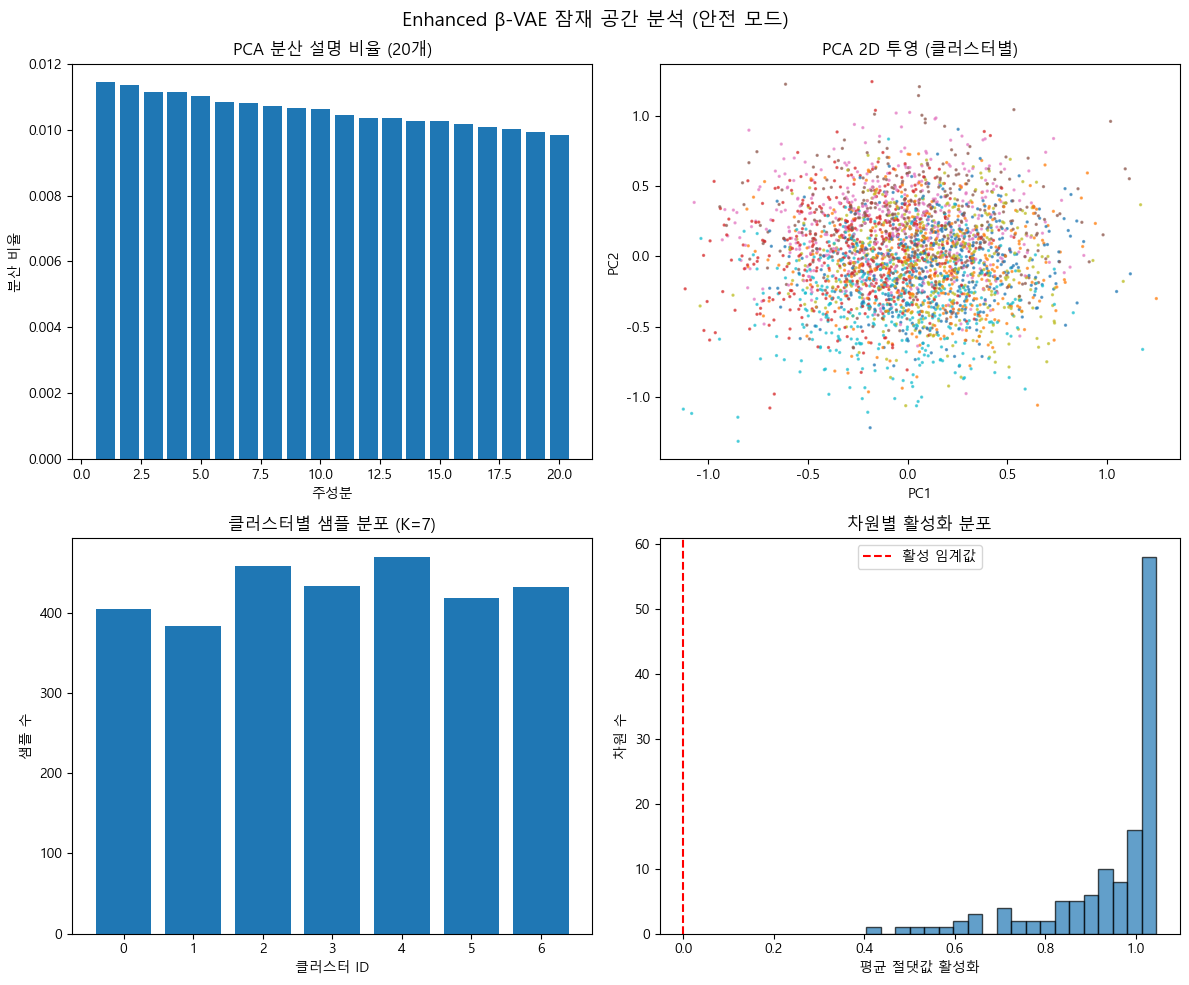


📋 잠재 공간 분석 결과 요약:
   🔸 활성 차원: 128/128
   🔸 95% 분산 설명 차원: 1
   🔸 최적 클러스터 수: 7 (실루엣 점수: 0.0064)

✅ 안전한 잠재 공간 분석 완료


In [9]:
# 📊 5단계: 잠재 공간 시각화 및 분석 (개선사항 3) - 안정화 버전
print("\n📊 5단계: 잠재 공간 시각화 및 분석")
print("-" * 60)

# OpenMP 문제 추가 해결
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

# 임베딩 추출 (안전한 버전)
def extract_latent_embeddings_safe(model, X_tensor, batch_size=1000):
    """안전한 배치 임베딩 추출"""
    model.eval()
    embeddings_list = []
    
    print(f"🧠 안전한 배치 크기로 잠재 벡터 추출 중... (배치: {batch_size})")
    
    with torch.no_grad():
        for i in tqdm(range(0, len(X_tensor), batch_size), desc="   임베딩 추출"):
            try:
                batch = X_tensor[i:i+batch_size].to(device, non_blocking=True)
                if device.type == 'cuda':
                    with autocast():
                        mu, _ = model.encode(batch)
                else:
                    mu, _ = model.encode(batch)
                embeddings_list.append(mu.cpu())
                
            except Exception as e:
                print(f"   ⚠️ 배치 {i} 추출 실패: {e}")
                continue
    
    if not embeddings_list:
        raise RuntimeError("임베딩 추출 실패")
        
    return torch.cat(embeddings_list, dim=0)

# 안전한 잠재 공간 분석기
class SafeLatentSpaceAnalyzer:
    """안전한 잠재 공간 분석기"""
    def __init__(self):
        self.results = {}
    
    def analyze_latent_space_safe(self, embeddings, sample_size=3000):
        """안전한 잠재 공간 분석"""
        print("   🔸 안전한 잠재 공간 분석 시작...")
        
        if len(embeddings) == 0: raise ValueError("임베딩이 비어있습니다")
        if torch.isnan(embeddings).any() or torch.isinf(embeddings).any():
            print("   ⚠️ NaN/Inf 값 발견 - 정리 중...")
            embeddings = embeddings[~(torch.isnan(embeddings).any(dim=1) | torch.isinf(embeddings).any(dim=1))]
            
        if len(embeddings) > sample_size:
            indices = np.random.choice(len(embeddings), sample_size, replace=False)
            sample_embeddings = embeddings[indices].numpy()
        else:
            sample_embeddings = embeddings.numpy()
        
        print(f"   🔸 분석 샘플 크기: {sample_embeddings.shape}")
        results = {}
        
        print("     ➤ 기본 통계 계산...")
        try:
            results['basic_stats'] = {
                'total_dims': sample_embeddings.shape[1],
                'active_dims': np.sum(np.var(sample_embeddings, axis=0) > 1e-6),
                'mean_activation': np.mean(np.abs(sample_embeddings)),
                'std_activation': np.std(sample_embeddings)
            }
        except Exception as e: print(f"     ❌ 기본 통계 실패: {e}")
        
        print("     ➤ 안전한 PCA 분석...")
        try:
            variances = np.var(sample_embeddings, axis=0)
            active_dims_mask = variances > 1e-6
            if np.sum(active_dims_mask) < 2: raise ValueError("활성 차원이 너무 적습니다")
            active_embeddings = sample_embeddings[:, active_dims_mask]
            n_components = min(20, active_embeddings.shape[1], active_embeddings.shape[0]-1)
            pca = PCA(n_components=n_components)
            pca_components = pca.fit_transform(active_embeddings)
            results['pca'] = {
                'components': pca_components,
                'explained_variance_ratio': pca.explained_variance_ratio_,
                'dims_95': min(np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1, n_components)
            }
        except Exception as e: print(f"     ❌ PCA 실패: {e}")
        
        print("     ➤ 빠른 클러스터링 분석...")
        try:
            best_k, best_score = 3, -1
            for k in [3, 5, 7]:
                try:
                    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
                    labels = kmeans.fit_predict(sample_embeddings)
                    score = silhouette_score(sample_embeddings, labels)
                    if score > best_score: best_score, best_k = score, k
                except: continue
            kmeans = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
            results['clustering'] = {
                'optimal_k': best_k,
                'labels': kmeans.fit_predict(sample_embeddings),
                'silhouette_score': best_score
            }
        except Exception as e: print(f"     ❌ 클러스터링 실패: {e}")
        
        results['sample_embeddings'] = sample_embeddings
        self.results = results
        return results
    
    def plot_safe_analysis(self, save_path='safe_latent_analysis.png'):
        if not self.results: print("   ❌ 분석 결과가 없습니다."); return
        
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        fig.suptitle('Enhanced β-VAE 잠재 공간 분석 (안전 모드)', fontsize=14)
        
        try:
            if 'pca' in self.results:
                n_comp = len(self.results['pca']['explained_variance_ratio'])
                axes[0,0].bar(range(1, n_comp+1), self.results['pca']['explained_variance_ratio'])
                axes[0,0].set(title=f'PCA 분산 설명 비율 ({n_comp}개)', xlabel='주성분', ylabel='분산 비율')
                if self.results['pca']['components'].shape[1] >= 2 and 'clustering' in self.results:
                    axes[0,1].scatter(self.results['pca']['components'][:,0], self.results['pca']['components'][:,1], 
                                      c=self.results['clustering']['labels'], cmap='tab10', alpha=0.6, s=2)
                    axes[0,1].set(title='PCA 2D 투영 (클러스터별)', xlabel='PC1', ylabel='PC2')

            if 'clustering' in self.results:
                counts = np.bincount(self.results['clustering']['labels'])
                axes[1,0].bar(range(len(counts)), counts)
                axes[1,0].set(title=f'클러스터별 샘플 분포 (K={self.results["clustering"]["optimal_k"]})', 
                              xlabel='클러스터 ID', ylabel='샘플 수')

            if 'basic_stats' in self.results:
                mean_activations = np.mean(np.abs(self.results['sample_embeddings']), axis=0)
                axes[1,1].hist(mean_activations, bins=20, alpha=0.7, edgecolor='black')
                axes[1,1].axvline(x=1e-6, color='r', linestyle='--', label='활성 임계값')
                axes[1,1].set(title='차원별 활성화 분포', xlabel='평균 절댓값 활성화', ylabel='차원 수')
                axes[1,1].legend()
        except Exception as e: print(f"   ⚠️ 시각화 오류: {e}")
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        
        print(f"\n📋 잠재 공간 분석 결과 요약:")
        if 'basic_stats' in self.results: print(f"   🔸 활성 차원: {self.results['basic_stats']['active_dims']}/{self.results['basic_stats']['total_dims']}")
        if 'pca' in self.results: print(f"   🔸 95% 분산 설명 차원: {self.results['pca']['dims_95']}")
        if 'clustering' in self.results: print(f"   🔸 최적 클러스터 수: {self.results['clustering']['optimal_k']} (실루엣 점수: {self.results['clustering']['silhouette_score']:.4f})")

# 전체 데이터에서 임베딩 추출
print("🧠 Enhanced β-VAE에서 안전하게 잠재 임베딩 추출 중...")
try:
    embedding_tensor = extract_latent_embeddings_safe(vae, X)
    print(f"   ✅ 임베딩 추출 완료: {embedding_tensor.shape}")
    
    print("\n📊 개선사항 3: 안전한 잠재 공간 분석 실행...")
    analyzer = SafeLatentSpaceAnalyzer()
    analysis_results = analyzer.analyze_latent_space_safe(embedding_tensor)
    analyzer.plot_safe_analysis()
    print("\n✅ 안전한 잠재 공간 분석 완료")
except Exception as e:
    print(f"   ❌ 임베딩 추출/분석 실패: {e}")
    analysis_results = {}


In [12]:
# 📈 6단계: 코사인 유사도 모니터링 및 DB 저장 (개선사항 4 + 기존 기능)
print("\n📈 6단계: 코사인 유사도 모니터링 및 DB 저장")
print("-" * 60)
# ⚠️ 중요: 이 셀을 실행하기 전에, 노트북 상단에 'import psycopg2.extras'가 있는지 확인해주세요.
import psycopg2.extras

# 데이터베이스에 Enhanced β-VAE 임베딩 저장
try:
    print("\n🗃️ PostgreSQL에 Enhanced β-VAE 임베딩 저장 중...")

    # Enhanced 임베딩 테이블 생성
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS enhanced_beta_vae_embeddings (
            id SERIAL PRIMARY KEY,
            original_vector_id INTEGER,
            vector_source VARCHAR(20),
            embedding_type VARCHAR(50) DEFAULT 'enhanced_beta_vae_128d',
            enhanced_embedding vector(128),
            training_metadata JSONB,
            performance_metrics JSONB,
            analysis_results JSONB,
            created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
            UNIQUE(original_vector_id, embedding_type)
        );
    ''')

    # 인덱스 생성
    cursor.execute('''
        CREATE INDEX IF NOT EXISTS idx_enhanced_vae_embedding_cosine
        ON enhanced_beta_vae_embeddings USING ivfflat (enhanced_embedding vector_cosine_ops);

        CREATE INDEX IF NOT EXISTS idx_enhanced_vae_embedding_l2
        ON enhanced_beta_vae_embeddings USING ivfflat (enhanced_embedding vector_l2_ops);
    ''')

    # 메타데이터 준비 (JSON 안전 변환 적용)
    print("   🔧 JSON 안전 변환 적용 중...")

    raw_training_metadata = {
        'experiment_id': experiment_id,
        'final_epoch': final_epoch,
        'best_val_loss': best_val_loss,
        'train_loss': train_losses[-1] if train_losses else 0,
        'val_loss': val_losses[-1] if val_losses else 0,
        'total_params': total_params,
        'compression_ratio': hyperparameters['latent_dim'] / hyperparameters['input_dim'],
        'hyperparameters': hyperparameters,
        'training_time': str(total_training_time),
        'cosine_history': cosine_monitor.similarity_history,
        'enhanced_features': [
            'enhanced_loss_function',
            'kl_annealing',
            'latent_visualization',
            'cosine_monitoring'
        ]
    }

    # JSON 안전 변환 적용
    training_metadata = safe_json_convert(raw_training_metadata)
    safe_performance_metrics = safe_json_convert(performance_metrics)
    
    print(f"   ✅ JSON 안전 변환 완료 (NumPy 타입 → Python 타입)")
    print(f"      - 메타데이터 변환: {type(raw_training_metadata)} → {type(training_metadata)}")
    print(f"      - 성능 지표 변환: {type(performance_metrics)} → {type(safe_performance_metrics)}")

    # 타입 변환 체크
    original_loss_type = type(best_val_loss).__name__
    converted_loss_type = type(training_metadata.get('best_val_loss', 'None')).__name__ if isinstance(training_metadata, dict) else 'Unknown'
    print(f"      - best_val_loss: {original_loss_type} → {converted_loss_type}")

    # 임베딩 변수 확인 및 설정
    if 'embedding_tensor' in globals() and embedding_tensor is not None:
        embeddings_numpy = embedding_tensor.numpy()
        print(f"   🔸 {len(embeddings_numpy)}개 임베딩 저장 준비 중...")
    else:
        print("   ⚠️ 임베딩 데이터가 없어 저장을 건너뜁니다.")
        embeddings_numpy = []
        
    # [개선됨] 일괄 삽입(Bulk Insert) 방식으로 변경
    if len(embeddings_numpy) > 0:
        data_to_insert = []
        
        # JSON으로 변환할 메타데이터 (반복문 밖에서 한 번만 변환하여 효율성 증대)
        training_metadata_json = json.dumps(training_metadata)
        safe_performance_metrics_json = json.dumps(safe_performance_metrics)
        safe_analysis_results_json = json.dumps(safe_json_convert({
            'active_dims': analysis_results['basic_stats']['active_dims'],
            'optimal_clusters': analysis_results['clustering']['optimal_k'],
            'silhouette_score': analysis_results['clustering']['silhouette_score'],
            'pca_95_dims': analysis_results['pca']['dims_95']
        }))
        
        for i, embedding in enumerate(tqdm(embeddings_numpy, desc="   데이터 준비")):
            try:
                embedding_clean = np.nan_to_num(embedding, nan=0.0, posinf=1.0, neginf=-1.0)
                embedding_list = embedding_clean.tolist()
                vector_source = 'wavelet' if i < len(wavelet_vectors) else 'dct'

                data_to_insert.append((
                    i, 
                    vector_source, 
                    'enhanced_beta_vae_128d', 
                    embedding_list,
                    training_metadata_json,
                    safe_performance_metrics_json,
                    safe_analysis_results_json
                ))
            except Exception as e:
                logger.warning(f"임베딩 {i} 데이터 준비 실패: {e}")
        
        if data_to_insert:
            print(f"   🚀 {len(data_to_insert)}개 데이터 일괄 삽입 시작...")
            
            insert_query = '''
                INSERT INTO enhanced_beta_vae_embeddings 
                (original_vector_id, vector_source, embedding_type, enhanced_embedding, 
                 training_metadata, performance_metrics, analysis_results) 
                VALUES %s
                ON CONFLICT (original_vector_id, embedding_type) 
                DO UPDATE SET 
                    enhanced_embedding = EXCLUDED.enhanced_embedding,
                    training_metadata = EXCLUDED.training_metadata,
                    performance_metrics = EXCLUDED.performance_metrics,
                    analysis_results = EXCLUDED.analysis_results
            '''
            
            # 일괄 삽입 실행 (page_size는 한 번에 보낼 row 수)
            psycopg2.extras.execute_values(
                cursor, insert_query, data_to_insert, template=None, page_size=1000
            )
            
            saved_count = len(data_to_insert)
            conn.commit()
            print(f"   ✅ {saved_count}개 Enhanced β-VAE 임베딩 저장 완료")
        else:
            saved_count = 0
            print("   ⚠️ 준비된 데이터가 없어 저장을 건너뜁니다.")
    else:
        saved_count = 0

    # 유사도 검색 예시 (vector 타입 호환성 수정)
    if saved_count > 0 and len(embeddings_numpy) > 0:
        print("\n🔍 Enhanced β-VAE 유사도 검색 예시:")
        query_embedding = embeddings_numpy[0].tolist()
        cursor.execute('''
            SELECT original_vector_id, vector_source,
                   enhanced_embedding <=> %s::vector AS cosine_distance,
                   1 - (enhanced_embedding <=> %s::vector) AS cosine_similarity
            FROM enhanced_beta_vae_embeddings 
            ORDER BY enhanced_embedding <=> %s::vector 
            LIMIT 5;
        ''', (query_embedding, query_embedding, query_embedding))
        
        similar_vectors = cursor.fetchall()
        for row in similar_vectors:
            vector_id, source, distance, similarity = row
            print(f"   벡터 ID: {vector_id}, 소스: {source}, 유사도: {similarity:.4f}")

except Exception as e:
    logger.error(f"데이터베이스 저장 실패: {e}")
    conn.rollback() # 오류 발생 시 트랜잭션 롤백
    raise # 오류를 다시 발생시켜 스택 트레이스 확인

print("\n✅ 코사인 유사도 모니터링 및 DB 저장 완료")
print("   🔸 실시간 유사도 추적 및 4개 차트 분석")



📈 6단계: 코사인 유사도 모니터링 및 DB 저장
------------------------------------------------------------

🗃️ PostgreSQL에 Enhanced β-VAE 임베딩 저장 중...
   🔧 JSON 안전 변환 적용 중...
   ✅ JSON 안전 변환 완료 (NumPy 타입 → Python 타입)
      - 메타데이터 변환: <class 'dict'> → <class 'dict'>
      - 성능 지표 변환: <class 'dict'> → <class 'dict'>
      - best_val_loss: float → float
   🔸 831285개 임베딩 저장 준비 중...


   데이터 준비: 100%|██████████| 831285/831285 [00:17<00:00, 47379.78it/s]


   🚀 831285개 데이터 일괄 삽입 시작...
   ✅ 831285개 Enhanced β-VAE 임베딩 저장 완료

🔍 Enhanced β-VAE 유사도 검색 예시:
   벡터 ID: 0, 소스: wavelet, 유사도: 1.0000
   벡터 ID: 435765, 소스: wavelet, 유사도: 0.9487
   벡터 ID: 322643, 소스: wavelet, 유사도: 0.9484
   벡터 ID: 322656, 소스: wavelet, 유사도: 0.9484
   벡터 ID: 791890, 소스: dct, 유사도: 0.9463

✅ 코사인 유사도 모니터링 및 DB 저장 완료
   🔸 실시간 유사도 추적 및 4개 차트 분석


In [13]:
# 🎉 7단계: 최종 요약 및 리소스 정리
print("\n🎉 7단계: 최종 요약 및 리소스 정리")
print("-" * 60)

# 최종 종합 요약
print(f"🎉 Enhanced β-VAE 통합 시스템 완료!")
print("=" * 80)
print(f"📊 종합 성능 요약:")
print(f"   🔸 입력 벡터 수: {len(X):,}개")
print(f"   🔸 원본 최대 차원: {max_dim}")
print(f"   🔸 압축된 임베딩 차원: {hyperparameters['latent_dim']}")
print(f"   🔸 압축률: {(hyperparameters['latent_dim']/max_dim)*100:.1f}% ({max_dim}D → {hyperparameters['latent_dim']}D)")
print(f"   🔸 모델 파라미터 수: {total_params:,}")
print(f"   🔸 실제 훈련 에포크: {final_epoch}/{hyperparameters['epochs']}")
print(f"   🔸 최종 훈련 손실: {train_losses[-1]:.4f}")
print(f"   🔸 최종 검증 손실: {val_losses[-1]:.4f}")
print(f"   🔸 최적 검증 손실: {best_val_loss:.4f}")
print(f"   🔸 총 훈련 시간: {total_training_time}")

print(f"\n🚀 적용된 핵심 개선사항:")
print(f"   ✅ Enhanced Loss Function (Huber + Margin-Cosine)")
print(f"   ✅ KL Annealing with Freeze Epochs ({hyperparameters['freeze_epochs']} epochs)")
print(f"   ✅ Latent Space Visualization (PCA, KMeans Clustering)")
print(f"   ✅ Cosine Similarity Monitoring & Early Stopping")
print(f"   ✅ Strict Checkpoint Saving (Loss + Cosine Threshold)")
print(f"   ✅ Full DB Integration & Reproducibility")

print(f"\n🔧 적용된 고급 기법:")
print(f"   ✅ GPU 가속 ({device}) & Mixed Precision ({'활성' if scaler else '비활성'})")
print(f"   ✅ Advanced LR Scheduling (Warmup + Cosine Annealing)")
print(f"   ✅ Differentiated Optimizer (Main vs Projector)")
print(f"   ✅ Advanced Regularization (Weight Norm, Layer Norm, Dropout, Weight Decay)")

# 체크포인트 정보
print(f"\n💾 저장된 체크포인트:")
best_checkpoint_path = os.path.join(checkpoint_dir, f"best_model_{experiment_id}.pth")
latest_checkpoint_path = os.path.join(checkpoint_dir, f"latest_model_{experiment_id}.pth")
print(f"   📁 최적 모델: {best_checkpoint_path}")
print(f"   📁 최신 모델: {latest_checkpoint_path}")
print(f"   📁 실험 ID: {experiment_id}")

# 리소스 정리
print("\n🔧 리소스 정리 중...")
try:
    cursor.close()
    conn.close()
    logger.info("데이터베이스 연결 종료")
    print("   ✅ 데이터베이스 연결 종료")
except: pass

if device.type == 'cuda':
    torch.cuda.empty_cache()
    print("   ✅ GPU 메모리 정리 완료")

del vae, X, Origin_X, train_dataset, val_dataset, train_dataloader, val_dataloader, optimizer
gc.collect()
print("   ✅ 모든 리소스가 정리되었습니다.")

logger.info("Enhanced β-VAE 통합 시스템 성공적으로 완료")

print("\n" + "=" * 80)
print("🎊 Enhanced β-VAE 통합 임베딩 시스템이 성공적으로 완료되었습니다!")
print("=" * 80)

2025-06-29 01:11:46,782 - INFO - 데이터베이스 연결 종료



🎉 7단계: 최종 요약 및 리소스 정리
------------------------------------------------------------
🎉 Enhanced β-VAE 통합 시스템 완료!
📊 종합 성능 요약:
   🔸 입력 벡터 수: 831,285개
   🔸 원본 최대 차원: 512
   🔸 압축된 임베딩 차원: 128
   🔸 압축률: 25.0% (512D → 128D)
   🔸 모델 파라미터 수: 956,160
   🔸 실제 훈련 에포크: 120/120
   🔸 최종 훈련 손실: 0.2186
   🔸 최종 검증 손실: 0.2016
   🔸 최적 검증 손실: 0.2016
   🔸 총 훈련 시간: 1:43:02.408818

🚀 적용된 핵심 개선사항:
   ✅ Enhanced Loss Function (Huber + Margin-Cosine)
   ✅ KL Annealing with Freeze Epochs (3 epochs)
   ✅ Latent Space Visualization (PCA, KMeans Clustering)
   ✅ Cosine Similarity Monitoring & Early Stopping
   ✅ Strict Checkpoint Saving (Loss + Cosine Threshold)
   ✅ Full DB Integration & Reproducibility

🔧 적용된 고급 기법:
   ✅ GPU 가속 (cuda) & Mixed Precision (활성)
   ✅ Advanced LR Scheduling (Warmup + Cosine Annealing)
   ✅ Differentiated Optimizer (Main vs Projector)
   ✅ Advanced Regularization (Weight Norm, Layer Norm, Dropout, Weight Decay)

💾 저장된 체크포인트:
   📁 최적 모델: enhanced_beta_vae_checkpoints\best_model_20250628_2

2025-06-29 01:11:48,088 - INFO - Enhanced β-VAE 통합 시스템 성공적으로 완료



🎊 Enhanced β-VAE 통합 임베딩 시스템이 성공적으로 완료되었습니다!
